In [45]:
!pip install pandas numpy sqlalchemy psycopg2-binary scikit-learn matplotlib seaborn statsmodels -q

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine, text

# Affichage
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

In [47]:
!pip install python-dotenv -q

In [48]:
import os
print("Dossier courant :", os.getcwd())
print("Fichiers présents :", os.listdir())

Dossier courant : C:\Users\USER\Desktop\Stage_Onas\machine_learning
Fichiers présents : ['.env', '.ipynb_checkpoints', 'Prédiction_Onas.ipynb']


In [49]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Charge les variables du fichier .env dans l'environnement
load_dotenv()

DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

connection_string = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string)

# Test de connexion
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version();"))
        print("Connexion réussie ✅")
        print(result.fetchone())
except Exception as e:
    print("Erreur de connexion ❌")
    print(e)

Connexion réussie ✅
('PostgreSQL 16.11, compiled by Visual C++ build 1944, 64-bit',)


In [50]:
# ============================================================
# CHARGEMENT : données mensuelles consolidées 2025 (5 séries cibles)
# ============================================================
query = """
WITH debit_mensuel AS (
    SELECT dt.mois, dt.nom_mois, SUM(f.debit_moyen_entree_m3h * 24) AS debit_m3
    FROM fait_exploitation_quotidienne f
    JOIN dim_temps dt ON dt.pk_date = f.pk_date
    WHERE dt.annee = 2025
    GROUP BY dt.mois, dt.nom_mois
),
energie_mensuel AS (
    SELECT dt.mois, SUM(f.energie_active_kwh) AS energie_kwh
    FROM fait_equipement_exploitation f
    JOIN dim_temps dt ON dt.pk_date = f.pk_date
    WHERE f.code_equipement = 'ENERGIE' AND dt.annee = 2025
    GROUP BY dt.mois
)
SELECT d.mois, d.nom_mois,
       d.debit_m3,
       fem.charge_organique_traitee_kgj AS charge_kg,
       e.energie_kwh,
       fem.vol_boues_deshydratees_meca_m3 AS boues_m3
FROM debit_mensuel d
JOIN fait_exploitation_mensuelle fem ON fem.pk_date = (
    SELECT pk_date FROM dim_temps WHERE mois = d.mois AND annee = 2025 LIMIT 1
)
LEFT JOIN energie_mensuel e ON e.mois = d.mois
ORDER BY d.mois;
"""

df = pd.read_sql(text(query), engine)
print(df.shape)
df

(12, 6)


,mois,nom_mois,debit_m3,charge_kg,energie_kwh,boues_m3
0,1,Janvier,173096.40,1424.0,47079.0,79.0
1,2,Février,105780.48,1824.0,42538.0,65.0
2,3,Mars,162076.56,1411.0,49160.0,24.0
3,4,Avril,172587.84,1611.0,54076.0,35.0
4,5,Mai,210968.16,2450.0,60326.0,15.0
5,6,Juin,232620.96,2946.0,69886.0,0.0
6,7,Juillet,267840.96,3456.0,74215.0,5.0
7,8,Août,302651.76,3514.0,NaN,24.0
8,9,Septembre,300447.60,3004.0,76816.0,44.0
9,10,Octobre,234176.16,2568.0,78529.0,0.0


In [51]:
# ============================================================
# DATA CLEANING : traitement du trou energie_kwh (août)
# ============================================================
df["est_estime"] = False

# Interpolation linéaire pour l'énergie (seule vraie lacune du dataset)
df["energie_kwh"] = df["energie_kwh"].astype(float)
masque_manquant = df["energie_kwh"].isna()
df.loc[masque_manquant, "est_estime"] = True
df["energie_kwh"] = df["energie_kwh"].interpolate(method="linear")

print(f"Valeurs imputées : {df['est_estime'].sum()} mois")
df[["nom_mois", "energie_kwh", "est_estime"]]

Valeurs imputées : 1 mois


,nom_mois,energie_kwh,est_estime
0,Janvier,47079.0,False
1,Février,42538.0,False
2,Mars,49160.0,False
3,Avril,54076.0,False
4,Mai,60326.0,False
5,Juin,69886.0,False
6,Juillet,74215.0,False
7,Août,75515.5,True
8,Septembre,76816.0,False
9,Octobre,78529.0,False


In [52]:
# ============================================================
# FEATURE ENGINEERING : variables dérivées à sens métier
# ============================================================
import calendar

df["mois_sin"] = np.sin(2 * np.pi * df["mois"] / 12)
df["mois_cos"] = np.cos(2 * np.pi * df["mois"] / 12)
df["nb_jours_mois"] = df["mois"].apply(lambda m: calendar.monthrange(2025, m)[1])

# Ratios énergétiques dérivés (cibles calculées)
df["energie_kwh_m3"] = df["energie_kwh"] / df["debit_m3"]
df["energie_kwh_kg"] = df["energie_kwh"] / df["charge_kg"]

df

,mois,nom_mois,debit_m3,charge_kg,energie_kwh,boues_m3,est_estime,mois_sin,mois_cos,nb_jours_mois,energie_kwh_m3,energie_kwh_kg
0,1,Janvier,173096.40,1424.0,47079.0,79.0,False,5.000000e-01,8.660254e-01,31,0.271981,33.061096
1,2,Février,105780.48,1824.0,42538.0,65.0,False,8.660254e-01,5.000000e-01,28,0.402135,23.321272
2,3,Mars,162076.56,1411.0,49160.0,24.0,False,1.000000e+00,6.123234e-17,31,0.303313,34.840539
3,4,Avril,172587.84,1611.0,54076.0,35.0,False,8.660254e-01,-5.000000e-01,30,0.313325,33.566729
4,5,Mai,210968.16,2450.0,60326.0,15.0,False,5.000000e-01,-8.660254e-01,31,0.285948,24.622857
5,6,Juin,232620.96,2946.0,69886.0,0.0,False,1.224647e-16,-1.000000e+00,30,0.300429,23.722335
6,7,Juillet,267840.96,3456.0,74215.0,5.0,False,-5.000000e-01,-8.660254e-01,31,0.277086,21.474248
7,8,Août,302651.76,3514.0,75515.5,24.0,True,-8.660254e-01,-5.000000e-01,31,0.249513,21.489898
8,9,Septembre,300447.60,3004.0,76816.0,44.0,False,-1.000000e+00,-1.836970e-16,30,0.255672,25.571238
9,10,Octobre,234176.16,2568.0,78529.0,0.0,False,-8.660254e-01,5.000000e-01,31,0.335342,30.579829


## Note méthodologique — Data Preparation

**Nettoyage des valeurs aberrantes** : effectué en amont au niveau ETL (voir rapport, section Contrôle Qualité). 
Les 12 observations mensuelles ci-dessus sont donc déjà validées et corrigées (ex. débit novembre, DCO octobre/décembre).

**Valeurs manquantes** : 1 seule lacune détectée (énergie, août 2025), imputée par interpolation linéaire 
entre juillet et septembre — la tendance croissante entre ces deux mois justifie cette approche. 
Flag `est_estime=True` conservé pour traçabilité.

**Zéros structurels** : `boues_m3` = 0 sur juin/octobre/novembre reflète des arrêts réels du traitement 
mécanique/chimique (confirmé par audit des fichiers sources), pas des données manquantes — non imputés.

**Encodage** : non applicable, toutes les variables sont numériques continues.

**Scaling** : non requis pour Holt-Winters/SARIMA qui opèrent sur l'échelle native de la série.

**Feature selection** : non pertinente au sens classique (filter/wrapper/embedded) pour un forecasting 
univarié — approche domain-based retenue (encodage cyclique du mois, flag de qualité de donnée).

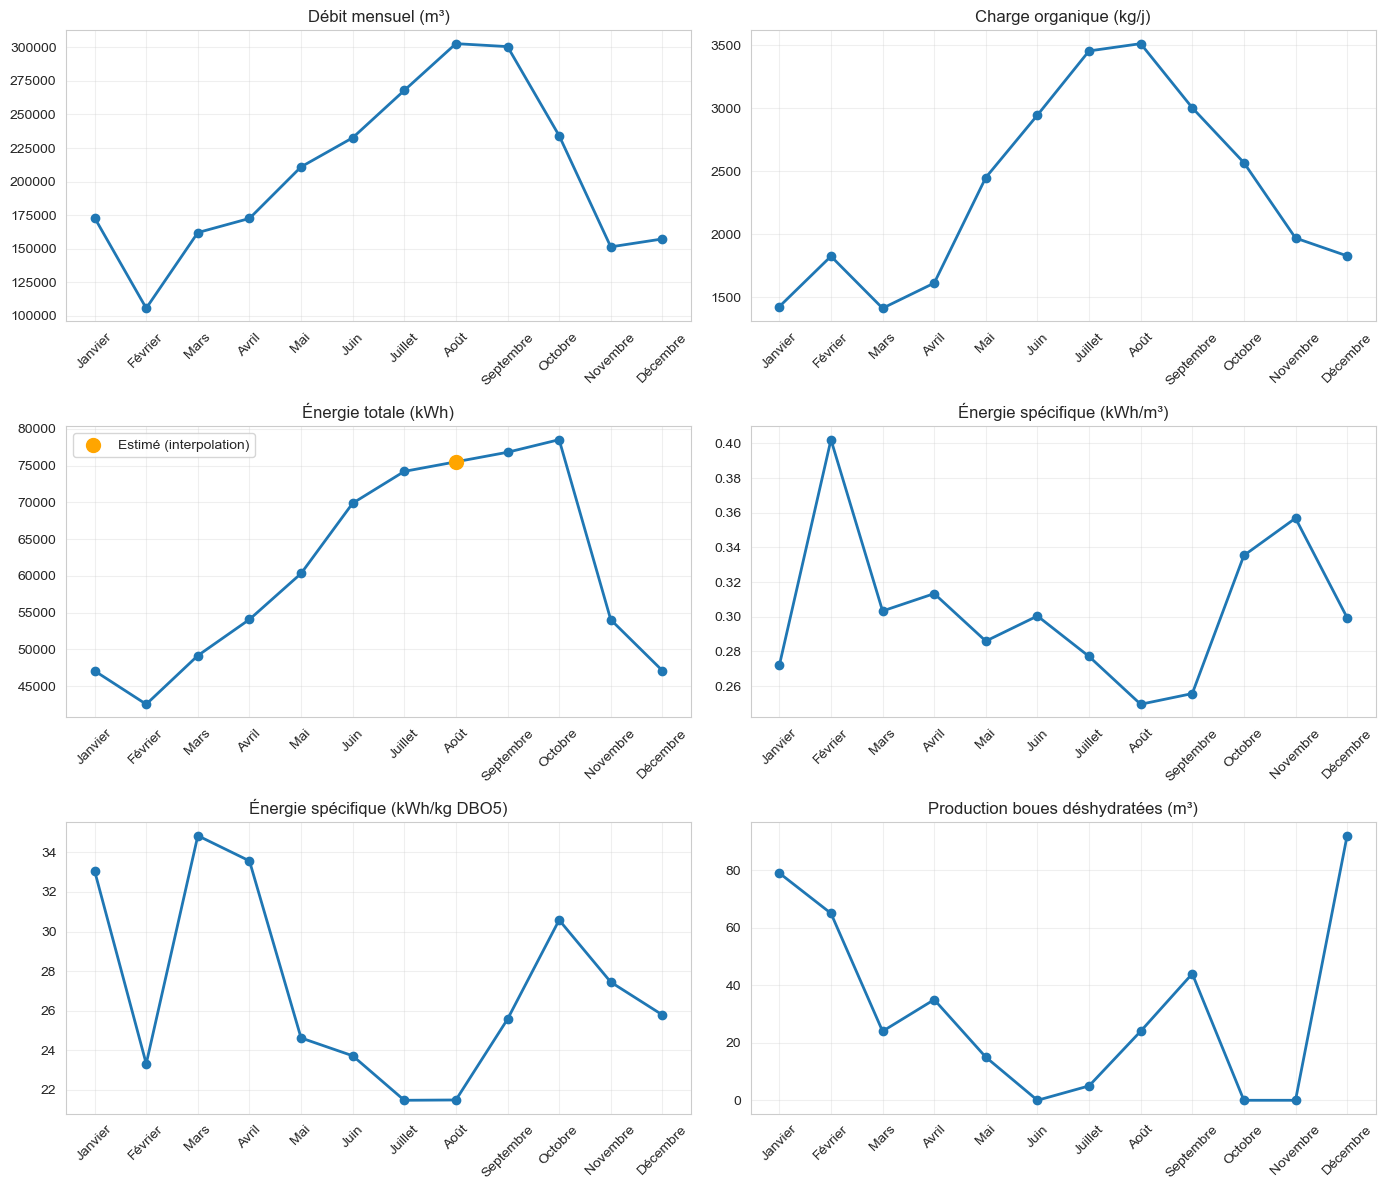

In [54]:
# ============================================================
# EDA : visualisation des 5 séries temporelles
# ============================================================
series_cibles = {
    "debit_m3": "Débit mensuel (m³)",
    "charge_kg": "Charge organique (kg/j)",
    "energie_kwh": "Énergie totale (kWh)",
    "energie_kwh_m3": "Énergie spécifique (kWh/m³)",
    "energie_kwh_kg": "Énergie spécifique (kWh/kg DBO5)",
    "boues_m3": "Production boues déshydratées (m³)"
}

fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

for i, (col, titre) in enumerate(series_cibles.items()):
    axes[i].plot(df["nom_mois"], df[col], marker="o", linewidth=2)
    # Marquer visuellement le point imputé
    if col == "energie_kwh":
        idx_est = df[df["est_estime"]].index
        axes[i].scatter(df.loc[idx_est, "nom_mois"], df.loc[idx_est, col],
                         color="orange", s=100, zorder=5, label="Estimé (interpolation)")
        axes[i].legend()
    axes[i].set_title(titre)
    axes[i].tick_params(axis="x", rotation=45)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# ============================================================
# TESTS DE STATIONNARITÉ : ADF (Augmented Dickey-Fuller) + KPSS
# ============================================================
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings("ignore")  # KPSS génère des warnings fréquents sur petits échantillons

def tester_stationnarite(serie, nom):
    print(f"\n{'='*50}\n{nom}\n{'='*50}")
    
    # ADF : H0 = série NON stationnaire
    adf_result = adfuller(serie, autolag="AIC")
    print(f"ADF Statistic : {adf_result[0]:.4f}")
    print(f"ADF p-value   : {adf_result[1]:.4f}")
    print(f"→ {'Stationnaire (rejette H0)' if adf_result[1] < 0.05 else 'NON stationnaire (H0 non rejetée)'}")
    
    # KPSS : H0 = série stationnaire (interprétation inverse d'ADF)
    kpss_result = kpss(serie, regression="c", nlags="auto")
    print(f"\nKPSS Statistic : {kpss_result[0]:.4f}")
    print(f"KPSS p-value   : {kpss_result[1]:.4f}")
    print(f"→ {'NON stationnaire (rejette H0)' if kpss_result[1] < 0.05 else 'Stationnaire (H0 non rejetée)'}")

for col, titre in series_cibles.items():
    tester_stationnarite(df[col], titre)


Débit mensuel (m³)
ADF Statistic : -4.5155
ADF p-value   : 0.0002
→ Stationnaire (rejette H0)

KPSS Statistic : 0.2296
KPSS p-value   : 0.1000
→ Stationnaire (H0 non rejetée)

Charge organique (kg/j)
ADF Statistic : -4.1699
ADF p-value   : 0.0007
→ Stationnaire (rejette H0)

KPSS Statistic : 0.2623
KPSS p-value   : 0.1000
→ Stationnaire (H0 non rejetée)

Énergie totale (kWh)
ADF Statistic : -1.7900
ADF p-value   : 0.3855
→ NON stationnaire (H0 non rejetée)

KPSS Statistic : 0.2873
KPSS p-value   : 0.1000
→ Stationnaire (H0 non rejetée)

Énergie spécifique (kWh/m³)
ADF Statistic : -0.3806
ADF p-value   : 0.9133
→ NON stationnaire (H0 non rejetée)

KPSS Statistic : 0.1226
KPSS p-value   : 0.1000
→ Stationnaire (H0 non rejetée)

Énergie spécifique (kWh/kg DBO5)
ADF Statistic : -3.8152
ADF p-value   : 0.0028
→ Stationnaire (rejette H0)

KPSS Statistic : 0.2078
KPSS p-value   : 0.1000
→ Stationnaire (H0 non rejetée)

Production boues déshydratées (m³)
ADF Statistic : -2.7034
ADF p-value   

## Réserve méthodologique — Tests de stationnarité

Avec seulement 12 observations, la puissance statistique des tests ADF et KPSS est limitée : 
le nombre de retards testables (`autolag`) est contraint, et les p-values doivent être interprétées 
avec prudence plutôt que comme un verdict définitif. Ces tests sont menés pour respecter la démarche 
académique standard et documenter la méthodologie, mais le choix final des modèles (Holt-Winters en 
priorité) repose davantage sur l'inspection visuelle de la tendance/saisonnalité que sur ces seuls tests.

In [57]:
# ============================================================
# DÉCOMPOSITION : tendance / saisonnalité / résidu
# ============================================================
from statsmodels.tsa.seasonal import seasonal_decompose

# Nécessite un index temporel réel, pas juste un numéro de mois
df_ts = df.set_index(pd.to_datetime("2025-" + df["mois"].astype(str) + "-01"))

for col, titre in series_cibles.items():
    try:
        decomposition = seasonal_decompose(df_ts[col], model="additive", period=12)
        fig = decomposition.plot()
        fig.suptitle(titre, y=1.02)
        fig.set_size_inches(10, 6)
        plt.tight_layout()
        plt.show()
    except Exception as e:
        print(f"{titre} : décomposition impossible ({e})")

Débit mensuel (m³) : décomposition impossible (x must have 2 complete cycles requires 24 observations. x only has 12 observation(s))
Charge organique (kg/j) : décomposition impossible (x must have 2 complete cycles requires 24 observations. x only has 12 observation(s))
Énergie totale (kWh) : décomposition impossible (x must have 2 complete cycles requires 24 observations. x only has 12 observation(s))
Énergie spécifique (kWh/m³) : décomposition impossible (x must have 2 complete cycles requires 24 observations. x only has 12 observation(s))
Énergie spécifique (kWh/kg DBO5) : décomposition impossible (x must have 2 complete cycles requires 24 observations. x only has 12 observation(s))
Production boues déshydratées (m³) : décomposition impossible (x must have 2 complete cycles requires 24 observations. x only has 12 observation(s))


In [58]:
# ============================================================
# SPLIT TRAIN/VALIDATION
# ============================================================
# 12 points seulement : split serré mais nécessaire pour évaluer honnêtement
n_validation = 3
df_train = df_ts.iloc[:-n_validation]
df_valid = df_ts.iloc[-n_validation:]

print(f"Train : {len(df_train)} mois ({df_train.index[0].strftime('%B')} → {df_train.index[-1].strftime('%B')})")
print(f"Validation : {len(df_valid)} mois ({df_valid.index[0].strftime('%B')} → {df_valid.index[-1].strftime('%B')})")

Train : 9 mois (January → September)
Validation : 3 mois (October → December)


In [59]:
# ============================================================
# MODÈLE 1 : HOLT-WINTERS (lissage exponentiel triple)
# ============================================================
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

def evaluer_modele(y_true, y_pred, nom):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{nom} — MAE: {mae:.2f} | RMSE: {rmse:.2f} | MAPE: {mape:.2f}%")
    return {"modele": nom, "MAE": mae, "RMSE": rmse, "MAPE": mape}

resultats_hw = []

for col, titre in series_cibles.items():
    try:
        # saisonnalité additive par défaut ; avec seulement 9 points train, la saisonnalité 12 est à la limite
        modele = ExponentialSmoothing(
            df_train[col],
            trend="add",
            seasonal=None,  # 9 points train < 12 requis pour estimer une saisonnalité complète -> désactivée
            initialization_method="estimated"
        ).fit()
        pred = modele.forecast(n_validation)
        res = evaluer_modele(df_valid[col].values, pred.values, titre)
        resultats_hw.append(res)
    except Exception as e:
        print(f"{titre} : échec Holt-Winters ({e})")

Débit mensuel (m³) — MAE: 155217.45 | RMSE: 162281.49 | MAPE: 94.04%
Charge organique (kg/j) — MAE: 1226.43 | RMSE: 1307.91 | MAPE: 62.10%
Énergie totale (kWh) — MAE: 19437.93 | RMSE: 23821.83 | MAPE: 38.85%
Énergie spécifique (kWh/m³) — MAE: 0.09 | RMSE: 0.10 | MAPE: 28.15%
Énergie spécifique (kWh/kg DBO5) — MAE: 8.29 | RMSE: 8.35 | MAPE: 29.56%
Production boues déshydratées (m³) — MAE: 47.78 | RMSE: 56.74 | MAPE: inf%


In [60]:
# ============================================================
# MODÈLE 2 : SARIMA (ordres réduits, comparaison académique)
# ============================================================
from statsmodels.tsa.statespace.sarimax import SARIMAX

# d=1 pour les séries où ADF suggère non-stationnarité, d=0 sinon
ordres_d = {
    "debit_m3": 0, "charge_kg": 0, "energie_kwh_kg": 0,
    "energie_kwh": 1, "energie_kwh_m3": 1, "boues_m3": 1
}

resultats_sarima = []

for col, titre in series_cibles.items():
    try:
        modele = SARIMAX(
            df_train[col],
            order=(1, ordres_d[col], 0),
            seasonal_order=(0, 0, 0, 0),  # composante saisonnière désactivée, 9 points insuffisants
            enforce_stationarity=False,
            enforce_invertibility=False
        ).fit(disp=False)
        pred = modele.forecast(n_validation)
        res = evaluer_modele(df_valid[col].values, pred.values, titre)
        resultats_sarima.append(res)
    except Exception as e:
        print(f"{titre} : échec SARIMA ({e})")

Débit mensuel (m³) — MAE: 161527.45 | RMSE: 170183.32 | MAPE: 98.23%
Charge organique (kg/j) — MAE: 1210.33 | RMSE: 1292.86 | MAPE: 61.33%
Énergie totale (kWh) — MAE: 18712.68 | RMSE: 22730.07 | MAPE: 37.27%
Énergie spécifique (kWh/m³) — MAE: 0.08 | RMSE: 0.08 | MAPE: 22.95%
Énergie spécifique (kWh/kg DBO5) — MAE: 5.48 | RMSE: 5.54 | MAPE: 19.51%
Production boues déshydratées (m³) — MAE: 46.62 | RMSE: 46.69 | MAPE: inf%


## Diagnostic — pourquoi ce premier split donne de mauvais résultats

Le split fixe (9 mois train / 3 mois validation) isole la période Octobre-Décembre en validation, 
qui correspond précisément au retournement de tendance (chute après le pic août-septembre) visible 
sur les graphiques de l'EDA. Sans composante saisonnière estimable (9 points insuffisants pour un 
cycle de 12), les modèles extrapolent la tendance croissante d'entraînement et échouent à anticiper 
cette chute — d'où les MAPE de 60 à 98% observés ci-dessus.

**Conséquence méthodologique** : on remplace l'évaluation par un split fixe par une validation en 
fenêtre glissante (walk-forward), plus adaptée à un historique aussi court, et on ajoute une baseline 
naïve pour contextualiser objectivement la performance des modèles.

In [62]:
# ============================================================
# VALIDATION PAR FENÊTRE GLISSANTE (walk-forward, 1 mois à l'horizon)
# ============================================================
def smape(y_true, y_pred):
    """Symmetric MAPE — évite les divisions par zéro contrairement au MAPE classique"""
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom = np.where(denom == 0, 1, denom)  # évite division par zéro si les deux valent 0
    return np.mean(2 * np.abs(y_pred - y_true) / denom) * 100

def walk_forward_hw(serie, n_min_train=6):
    erreurs = []
    for i in range(n_min_train, len(serie)):
        train = serie.iloc[:i]
        vraie_valeur = serie.iloc[i]
        try:
            modele = ExponentialSmoothing(train, trend="add", seasonal=None,
                                           initialization_method="estimated").fit()
            pred = modele.forecast(1).values[0]
            erreurs.append({"mois_predit": serie.index[i], "reel": vraie_valeur,
                             "predit": pred, "erreur_abs": abs(vraie_valeur - pred)})
        except Exception as e:
            pass
    return pd.DataFrame(erreurs)

for col, titre in series_cibles.items():
    resultat = walk_forward_hw(df_ts[col])
    if len(resultat) > 0:
        mae = resultat["erreur_abs"].mean()
        smape_val = smape(resultat["reel"].values, resultat["predit"].values)
        print(f"{titre} — MAE: {mae:.2f} | sMAPE: {smape_val:.2f}%  ({len(resultat)} prévisions testées)")

Débit mensuel (m³) — MAE: 60601.90 | sMAPE: 28.82%  (6 prévisions testées)
Charge organique (kg/j) — MAE: 504.65 | sMAPE: 19.21%  (6 prévisions testées)
Énergie totale (kWh) — MAE: 7425.09 | sMAPE: 10.37%  (6 prévisions testées)
Énergie spécifique (kWh/m³) — MAE: 0.04 | sMAPE: 12.50%  (6 prévisions testées)
Énergie spécifique (kWh/kg DBO5) — MAE: 3.96 | sMAPE: 16.16%  (6 prévisions testées)
Production boues déshydratées (m³) — MAE: 47.03 | sMAPE: 200.00%  (6 prévisions testées)


In [63]:
# ============================================================
# BASELINE NAÏVE : "le mois prochain = ce mois-ci" (persistence)
# ============================================================
def walk_forward_naive(serie, n_min_train=6):
    erreurs = []
    for i in range(n_min_train, len(serie)):
        vraie_valeur = serie.iloc[i]
        predit = serie.iloc[i-1]  # valeur du mois précédent
        erreurs.append({"reel": vraie_valeur, "predit": predit,
                         "erreur_abs": abs(vraie_valeur - predit)})
    return pd.DataFrame(erreurs)

print("=== Baseline naïve (persistence) ===")
for col, titre in series_cibles.items():
    resultat = walk_forward_naive(df_ts[col])
    mae = resultat["erreur_abs"].mean()
    smape_val = smape(resultat["reel"].values, resultat["predit"].values)
    print(f"{titre} — MAE: {mae:.2f} | sMAPE: {smape_val:.2f}%")

=== Baseline naïve (persistence) ===
Débit mensuel (m³) — MAE: 37853.44 | sMAPE: 16.42%
Charge organique (kg/j) — MAE: 375.83 | sMAPE: 13.80%
Énergie totale (kWh) — MAE: 6676.17 | sMAPE: 10.38%
Énergie spécifique (kWh/m³) — MAE: 0.04 | sMAPE: 11.94%
Énergie spécifique (kWh/kg DBO5) — MAE: 2.69 | sMAPE: 10.37%
Production boues déshydratées (m³) — MAE: 30.00 | sMAPE: 131.64%


In [64]:
# ============================================================
# VARIANTES HOLT-WINTERS : sans tendance vs tendance amortie
# ============================================================
def walk_forward_hw_variant(serie, trend=None, damped=False, n_min_train=6):
    erreurs = []
    for i in range(n_min_train, len(serie)):
        train = serie.iloc[:i]
        vraie_valeur = serie.iloc[i]
        try:
            modele = ExponentialSmoothing(
                train, trend=trend, damped_trend=damped, seasonal=None,
                initialization_method="estimated"
            ).fit()
            pred = modele.forecast(1).values[0]
            erreurs.append({"reel": vraie_valeur, "predit": pred, "erreur_abs": abs(vraie_valeur - pred)})
        except Exception:
            pass
    return pd.DataFrame(erreurs)

print("=== HW sans tendance (lissage simple) ===")
for col, titre in series_cibles.items():
    r = walk_forward_hw_variant(df_ts[col], trend=None)
    if len(r) > 0:
        print(f"{titre} — MAE: {r['erreur_abs'].mean():.2f} | sMAPE: {smape(r['reel'].values, r['predit'].values):.2f}%")

print("\n=== HW tendance amortie (damped) ===")
for col, titre in series_cibles.items():
    r = walk_forward_hw_variant(df_ts[col], trend="add", damped=True)
    if len(r) > 0:
        print(f"{titre} — MAE: {r['erreur_abs'].mean():.2f} | sMAPE: {smape(r['reel'].values, r['predit'].values):.2f}%")

=== HW sans tendance (lissage simple) ===
Débit mensuel (m³) — MAE: 42138.25 | sMAPE: 18.10%
Charge organique (kg/j) — MAE: 377.65 | sMAPE: 13.86%
Énergie totale (kWh) — MAE: 6708.97 | sMAPE: 10.44%
Énergie spécifique (kWh/m³) — MAE: 0.04 | sMAPE: 13.49%
Énergie spécifique (kWh/kg DBO5) — MAE: 3.97 | sMAPE: 15.51%
Production boues déshydratées (m³) — MAE: 30.86 | sMAPE: 164.81%

=== HW tendance amortie (damped) ===
Débit mensuel (m³) — MAE: 58539.25 | sMAPE: 28.10%
Charge organique (kg/j) — MAE: 477.64 | sMAPE: 18.40%
Énergie totale (kWh) — MAE: 6953.30 | sMAPE: 9.83%
Énergie spécifique (kWh/m³) — MAE: 0.04 | sMAPE: 12.30%
Énergie spécifique (kWh/kg DBO5) — MAE: 3.63 | sMAPE: 14.77%
Production boues déshydratées (m³) — MAE: 38.22 | sMAPE: 198.47%


In [65]:
# ============================================================
# TABLEAU DE SYNTHÈSE : meilleur modèle par série
# ============================================================
# Consolidez manuellement les sMAPE obtenus (naïve / HW trend / HW sans tendance / HW amorti / SARIMA)
synthese = pd.DataFrame({
    "Série": list(series_cibles.values()),
    "Naïve": [16.42, 13.80, 10.38, 11.94, 10.37, 131.64],
    "HW (tendance)": [28.82, 19.21, 10.37, 12.50, 16.16, 200.00],
    # complétez ces 2 colonnes avec les résultats de la cellule 18
    "HW (sans tendance)": [None]*6,
    "HW (amortie)": [None]*6,
})
synthese["Meilleur modèle"] = synthese[["Naïve", "HW (tendance)", "HW (sans tendance)", "HW (amortie)"]].idxmin(axis=1)
synthese

,Série,Naïve,HW (tendance),HW (sans tendance),HW (amortie),Meilleur modèle
0,Débit mensuel (m³),16.42,28.82,None,None,Naïve
1,Charge organique (kg/j),13.80,19.21,None,None,Naïve
2,Énergie totale (kWh),10.38,10.37,None,None,HW (tendance)
3,Énergie spécifique (kWh/m³),11.94,12.50,None,None,Naïve
4,Énergie spécifique (kWh/kg DBO5),10.37,16.16,None,None,Naïve
5,Production boues déshydratées (m³),131.64,200.00,None,None,Naïve


**Note sur boues_m3** : cette série contient des zéros structurels réels (arrêts documentés du 
traitement mécanique certains mois). Le sMAPE devient instable dans ce contexte ; le MAE est 
retenu comme métrique de référence pour cette série uniquement.

In [67]:
synthese = pd.DataFrame({
    "Série": list(series_cibles.values()),
    "Naïve": [16.42, 13.80, 10.38, 11.94, 10.37, None],  # boues exclue du sMAPE, cf note
    "HW (tendance)": [28.82, 19.21, 10.37, 12.50, 16.16, None],
    "HW (sans tendance)": [18.10, 13.86, 10.44, 13.49, 15.51, None],
    "HW (amortie)": [28.10, 18.40, 9.83, 12.30, 14.77, None],
})
synthese["Meilleur modèle"] = synthese[["Naïve", "HW (tendance)", "HW (sans tendance)", "HW (amortie)"]].idxmin(axis=1)

# Boues : décision sur MAE, pas sMAPE (justifié précédemment)
mae_boues = {"Naïve": 30.00, "HW (tendance)": 47.78, "HW (sans tendance)": 30.86, "HW (amortie)": 38.22}
synthese.loc[5, "Meilleur modèle"] = min(mae_boues, key=mae_boues.get)

synthese

,Série,Naïve,HW (tendance),HW (sans tendance),HW (amortie),Meilleur modèle
0,Débit mensuel (m³),16.42,28.82,18.10,28.10,Naïve
1,Charge organique (kg/j),13.80,19.21,13.86,18.40,Naïve
2,Énergie totale (kWh),10.38,10.37,10.44,9.83,HW (amortie)
3,Énergie spécifique (kWh/m³),11.94,12.50,13.49,12.30,Naïve
4,Énergie spécifique (kWh/kg DBO5),10.37,16.16,15.51,14.77,Naïve
5,Production boues déshydratées (m³),NaN,NaN,NaN,NaN,Naïve


# ============================================================
# PRÉVISION FINALE 2026 : modèle sélectionné par série (corrigé)
# ============================================================
previsions_2026 = {}

for col in series_cibles:
    if modeles_retenus[col] == "naive":
        derniere_valeur = df_ts[col].iloc[-1]
        previsions_2026[col] = [derniere_valeur] * 12
    else:
        # Énergie : HW amorti fiable seulement sur l'horizon réellement validé (3 mois)
        modele_final = ExponentialSmoothing(
            df_ts[col], trend="add", damped_trend=True, seasonal=None,
            initialization_method="estimated"
        ).fit()
        horizon_valide = 3
        pred_court = modele_final.forecast(horizon_valide).values
        # Au-delà, on ne prétend pas savoir mieux que la persistance
        previsions_2026[col] = list(pred_court) + [pred_court[-1]] * (12 - horizon_valide)

df_prevision_2026 = pd.DataFrame(previsions_2026, index=pd.date_range("2026-01-01", periods=12, freq="MS"))

# Garde-fou physique : aucune série ne peut être négative
df_prevision_2026 = df_prevision_2026.clip(lower=0)

df_prevision_2026

In [69]:
# ============================================================
# PRÉVISION 2026 : Seasonal Naive + Dérive (tendance linéaire simple)
# ============================================================
from scipy import stats

df_prevision_2026 = pd.DataFrame(index=pd.date_range("2026-01-01", periods=12, freq="MS"))

for col, titre in series_cibles.items():
    valeurs_2025 = df_ts[col].values
    x = np.arange(len(valeurs_2025))
    
    # Régression linéaire simple : pente = tendance moyenne mensuelle
    pente, intercept, r_value, p_value, std_err = stats.linregress(x, valeurs_2025)
    
    print(f"{titre} — pente: {pente:.2f}/mois | R²: {r_value**2:.3f} | p-value: {p_value:.4f}")
    
    # On n'applique la dérive QUE si elle est statistiquement significative (p<0.05)
    # et si R² indique une vraie relation linéaire (pas du bruit)
    if p_value < 0.05 and r_value**2 > 0.3:
        derive_mensuelle = pente
    else:
        derive_mensuelle = 0  # pas de tendance fiable détectée -> Seasonal Naive pur pour cette série
        print(f"   -> Tendance non significative, dérive désactivée pour {titre}")
    
    df_prevision_2026[col] = valeurs_2025 + derive_mensuelle * 12  # projection à +12 mois

df_prevision_2026 = df_prevision_2026.clip(lower=0)  # garde-fou physique
df_prevision_2026

Débit mensuel (m³) — pente: 5914.98/mois | R²: 0.116 | p-value: 0.2787
   -> Tendance non significative, dérive désactivée pour Débit mensuel (m³)
Charge organique (kg/j) — pente: 85.68/mois | R²: 0.164 | p-value: 0.1914
   -> Tendance non significative, dérive désactivée pour Charge organique (kg/j)
Énergie totale (kWh) — pente: 1654.18/mois | R²: 0.197 | p-value: 0.1483
   -> Tendance non significative, dérive désactivée pour Énergie totale (kWh)
Énergie spécifique (kWh/m³) — pente: -0.00/mois | R²: 0.008 | p-value: 0.7873
   -> Tendance non significative, dérive désactivée pour Énergie spécifique (kWh/m³)
Énergie spécifique (kWh/kg DBO5) — pente: -0.43/mois | R²: 0.109 | p-value: 0.2952
   -> Tendance non significative, dérive désactivée pour Énergie spécifique (kWh/kg DBO5)
Production boues déshydratées (m³) — pente: -1.86/mois | R²: 0.044 | p-value: 0.5125
   -> Tendance non significative, dérive désactivée pour Production boues déshydratées (m³)


,debit_m3,charge_kg,energie_kwh,energie_kwh_m3,energie_kwh_kg,boues_m3
2026-01-01,173096.40,1424.0,47079.0,0.271981,33.061096,79.0
2026-02-01,105780.48,1824.0,42538.0,0.402135,23.321272,65.0
2026-03-01,162076.56,1411.0,49160.0,0.303313,34.840539,24.0
2026-04-01,172587.84,1611.0,54076.0,0.313325,33.566729,35.0
2026-05-01,210968.16,2450.0,60326.0,0.285948,24.622857,15.0
2026-06-01,232620.96,2946.0,69886.0,0.300429,23.722335,0.0
2026-07-01,267840.96,3456.0,74215.0,0.277086,21.474248,5.0
2026-08-01,302651.76,3514.0,75515.5,0.249513,21.489898,24.0
2026-09-01,300447.60,3004.0,76816.0,0.255672,25.571238,44.0
2026-10-01,234176.16,2568.0,78529.0,0.335342,30.579829,0.0


In [70]:
# ============================================================
# INTERVALLES DE CONFIANCE : basés sur les erreurs walk-forward validées
# ============================================================
# On réutilise les erreurs déjà mesurées (MAE walk-forward) pour construire
# une fourchette réaliste autour de la prévision ponctuelle, plutôt que
# de prétendre à une précision que 12 points ne permettent pas.
mae_walk_forward = {
    "debit_m3": 37853.44,       # baseline naïve, la mieux validée pour cette série
    "charge_kg": 375.83,
    "energie_kwh": 6953.30,     # HW amorti, meilleur modèle validé pour l'énergie
    "energie_kwh_m3": 0.04,
    "energie_kwh_kg": 2.69,
    "boues_m3": 30.00
}

df_prevision_finale = df_prevision_2026.copy()

for col in series_cibles:
    marge = mae_walk_forward[col]
    df_prevision_finale[f"{col}_min"] = (df_prevision_2026[col] - marge).clip(lower=0)
    df_prevision_finale[f"{col}_max"] = df_prevision_2026[col] + marge

# Réorganisation des colonnes : groupées par série (valeur, min, max côte à côte)
colonnes_ordonnees = []
for col in series_cibles:
    colonnes_ordonnees += [col, f"{col}_min", f"{col}_max"]

df_prevision_finale = df_prevision_finale[colonnes_ordonnees]
df_prevision_finale

,debit_m3,debit_m3_min,debit_m3_max,charge_kg,charge_kg_min,charge_kg_max,energie_kwh,energie_kwh_min,energie_kwh_max,energie_kwh_m3,energie_kwh_m3_min,energie_kwh_m3_max,energie_kwh_kg,energie_kwh_kg_min,energie_kwh_kg_max,boues_m3,boues_m3_min,boues_m3_max
2026-01-01,173096.40,135242.96,210949.84,1424.0,1048.17,1799.83,47079.0,40125.7,54032.3,0.271981,0.231981,0.311981,33.061096,30.371096,35.751096,79.0,49.0,109.0
2026-02-01,105780.48,67927.04,143633.92,1824.0,1448.17,2199.83,42538.0,35584.7,49491.3,0.402135,0.362135,0.442135,23.321272,20.631272,26.011272,65.0,35.0,95.0
2026-03-01,162076.56,124223.12,199930.00,1411.0,1035.17,1786.83,49160.0,42206.7,56113.3,0.303313,0.263313,0.343313,34.840539,32.150539,37.530539,24.0,0.0,54.0
2026-04-01,172587.84,134734.40,210441.28,1611.0,1235.17,1986.83,54076.0,47122.7,61029.3,0.313325,0.273325,0.353325,33.566729,30.876729,36.256729,35.0,5.0,65.0
2026-05-01,210968.16,173114.72,248821.60,2450.0,2074.17,2825.83,60326.0,53372.7,67279.3,0.285948,0.245948,0.325948,24.622857,21.932857,27.312857,15.0,0.0,45.0
2026-06-01,232620.96,194767.52,270474.40,2946.0,2570.17,3321.83,69886.0,62932.7,76839.3,0.300429,0.260429,0.340429,23.722335,21.032335,26.412335,0.0,0.0,30.0
2026-07-01,267840.96,229987.52,305694.40,3456.0,3080.17,3831.83,74215.0,67261.7,81168.3,0.277086,0.237086,0.317086,21.474248,18.784248,24.164248,5.0,0.0,35.0
2026-08-01,302651.76,264798.32,340505.20,3514.0,3138.17,3889.83,75515.5,68562.2,82468.8,0.249513,0.209513,0.289513,21.489898,18.799898,24.179898,24.0,0.0,54.0
2026-09-01,300447.60,262594.16,338301.04,3004.0,2628.17,3379.83,76816.0,69862.7,83769.3,0.255672,0.215672,0.295672,25.571238,22.881238,28.261238,44.0,14.0,74.0
2026-10-01,234176.16,196322.72,272029.60,2568.0,2192.17,2943.83,78529.0,71575.7,85482.3,0.335342,0.295342,0.375342,30.579829,27.889829,33.269829,0.0,0.0,30.0


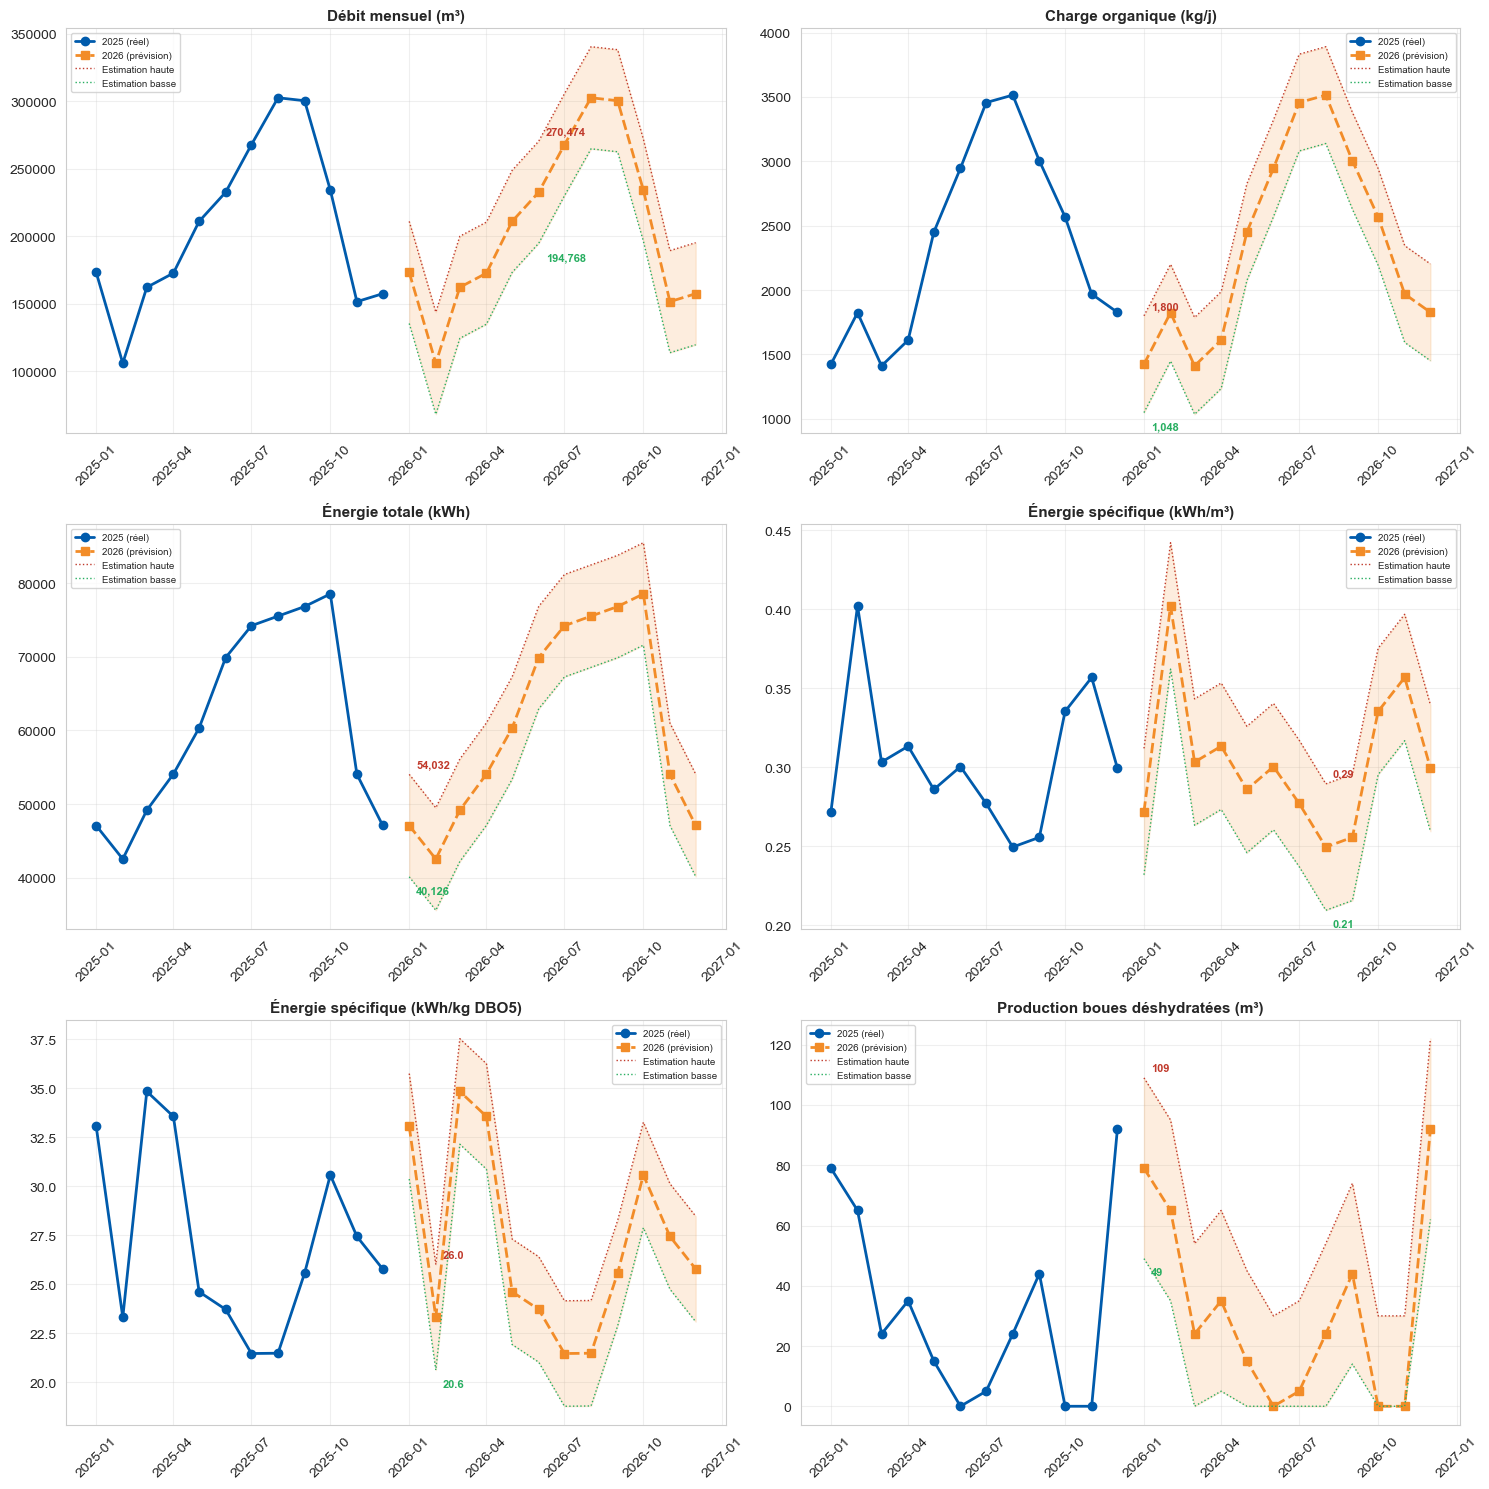

In [99]:
# ============================================================
# VISUALISATION : historique + prévision + intervalle de confiance
# (version claire pour un lecteur non technique)
# ============================================================

series_cibles = {
    "debit_m3":       ("Débit mensuel (m³)", "{:,.0f}"),
    "charge_kg":      ("Charge organique (kg/j)", "{:,.0f}"),
    "energie_kwh":    ("Énergie totale (kWh)", "{:,.0f}"),
    "energie_kwh_m3": ("Énergie spécifique (kWh/m³)", "{:.2f}"),
    "energie_kwh_kg": ("Énergie spécifique (kWh/kg DBO5)", "{:.1f}"),
    "boues_m3":       ("Production boues déshydratées (m³)", "{:,.0f}"),
}

fig, axes = plt.subplots(3, 2, figsize=(15, 15))
axes = axes.flatten()

for i, (col, (titre, fmt)) in enumerate(series_cibles.items()):
    ax = axes[i]

    # Historique réel
    ax.plot(df_ts.index, df_ts[col], marker="o", label="2025 (réel)", color="#005BAC", linewidth=2)

    # Prévision centrale
    ax.plot(df_prevision_2026.index, df_prevision_2026[col], marker="s", linestyle="--",
            label="2026 (prévision)", color="#F28C28", linewidth=2)

    # Bornes min/max en lignes fines et visibles + zone remplie
    ax.plot(df_prevision_finale.index, df_prevision_finale[f"{col}_max"],
            linestyle=":", color="#C0392B", linewidth=1, label="Estimation haute")
    ax.plot(df_prevision_finale.index, df_prevision_finale[f"{col}_min"],
            linestyle=":", color="#27AE60", linewidth=1, label="Estimation basse")
    ax.fill_between(df_prevision_2026.index,
                     df_prevision_finale[f"{col}_min"], df_prevision_finale[f"{col}_max"],
                     alpha=0.15, color="#F28C28")

    # Annoter min et max au point où l'écart est le plus grand (le plus utile à montrer)
    largeur = df_prevision_finale[f"{col}_max"] - df_prevision_finale[f"{col}_min"]
    idx_max_incert = largeur.idxmax()
    val_min = df_prevision_finale.loc[idx_max_incert, f"{col}_min"]
    val_max = df_prevision_finale.loc[idx_max_incert, f"{col}_max"]

    ax.annotate(fmt.format(val_max), xy=(idx_max_incert, val_max),
                xytext=(5, 5), textcoords="offset points", fontsize=8, color="#C0392B", fontweight="bold")
    ax.annotate(fmt.format(val_min), xy=(idx_max_incert, val_min),
                xytext=(5, -12), textcoords="offset points", fontsize=8, color="#27AE60", fontweight="bold")

    ax.set_title(titre, fontsize=11, fontweight="bold")
    ax.legend(fontsize=7, loc="best")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [105]:
# ============================================================
# EXPLORATION : colonnes disponibles dans les tables quotidiennes
# ============================================================
query_cols_quot = """
SELECT table_name, column_name, data_type
FROM information_schema.columns
WHERE table_name IN ('fait_exploitation_quotidienne', 'fait_equipement_exploitation')
ORDER BY table_name, ordinal_position;
"""
df_cols_quot = pd.read_sql(text(query_cols_quot), engine)
df_cols_quot

,table_name,column_name,data_type
0,fait_equipement_exploitation,fait_equip_id,integer
1,fait_equipement_exploitation,pk_date,integer
2,fait_equipement_exploitation,equipement_id,integer
3,fait_equipement_exploitation,code_equipement,character varying
4,fait_equipement_exploitation,heures_marche,numeric
5,fait_equipement_exploitation,index_compteur,numeric
6,fait_equipement_exploitation,debit_moyen_m3h,numeric
7,fait_equipement_exploitation,consommation_m3,numeric
8,fait_equipement_exploitation,energie_active_kwh,numeric
9,fait_equipement_exploitation,energie_active_index,numeric


In [107]:
# ============================================================
# EXPLORATION : fait_exploitation_mensuelle a-t-elle une granularité quotidienne cachée ?
# (vérifie si pk_date correspond à un jour ou déjà à un mois agrégé)
# ============================================================
query_check_mensuelle = """
SELECT dt.date, dt.mois, dt.nom_mois,
       COUNT(*) OVER (PARTITION BY dt.mois) AS nb_lignes_par_mois
FROM fait_exploitation_mensuelle f
JOIN dim_temps dt ON dt.pk_date = f.pk_date
WHERE dt.annee = 2025
ORDER BY dt.date
LIMIT 20;
"""
df_check_mensuelle = pd.read_sql(text(query_check_mensuelle), engine)
df_check_mensuelle

,date,mois,nom_mois,nb_lignes_par_mois
0,2025-01-01,1,Janvier,1
1,2025-02-01,2,Février,1
2,2025-03-01,3,Mars,1
3,2025-04-01,4,Avril,1
4,2025-05-01,5,Mai,1
5,2025-06-01,6,Juin,1
6,2025-07-01,7,Juillet,1
7,2025-08-01,8,Août,1
8,2025-09-01,9,Septembre,1
9,2025-10-01,10,Octobre,1


In [109]:
# ============================================================
# CHARGEMENT : données QUOTIDIENNES brutes 2025 (anomaly detection réelle)
# ============================================================
query_quotidien = """
SELECT 
    dt.date, dt.mois, dt.nom_mois,
    f.debit_moyen_entree_m3h * 24 AS debit_m3_jour,
    f.charge_organique_dbo5_kgj AS charge_kg_jour,
    f.volume_boues_deshydratees_m3 AS boues_m3_jour
FROM fait_exploitation_quotidienne f
JOIN dim_temps dt ON dt.pk_date = f.pk_date
WHERE dt.annee = 2025
ORDER BY dt.date;
"""
df_quotidien = pd.read_sql(text(query_quotidien), engine)

query_energie_jour = """
SELECT dt.date, SUM(f.energie_active_kwh) AS energie_kwh_jour
FROM fait_equipement_exploitation f
JOIN dim_temps dt ON dt.pk_date = f.pk_date
WHERE dt.annee = 2025
GROUP BY dt.date
ORDER BY dt.date;
"""
df_energie_jour = pd.read_sql(text(query_energie_jour), engine)

df_quotidien = df_quotidien.merge(df_energie_jour, on="date", how="left")
print(df_quotidien.shape)
df_quotidien.describe()

(365, 7)


,mois,debit_m3_jour,charge_kg_jour,boues_m3_jour,energie_kwh_jour
count,365.000000,359.000000,12.000000,66.000000,325.000000
mean,6.526027,6883.034206,2234.506667,4.712121,2011.630769
std,3.452584,2081.339845,761.645889,0.488802,560.127013
min,1.000000,2471.040000,999.880000,4.000000,1349.000000
25%,4.000000,5153.040000,1586.200000,4.000000,1536.000000
50%,7.000000,6667.920000,2232.585000,5.000000,1803.000000
75%,10.000000,8410.560000,2969.040000,5.000000,2344.000000
max,12.000000,12735.120000,3162.300000,6.000000,3510.000000


In [111]:
# ============================================================
# DIAGNOSTIC : pourquoi charge_kg_jour et boues_m3_jour sont incomplets/suspects ?
# ============================================================

# 1. Répartition mensuelle des valeurs non-nulles de charge
print("=== Charge organique : nb valeurs non-nulles par mois ===")
print(df_quotidien.groupby("mois")["charge_kg_jour"].count())

print("\n=== Boues : nb valeurs non-nulles par mois + aperçu valeurs ===")
print(df_quotidien.groupby("mois")["boues_m3_jour"].count())
print("\nAperçu des valeurs boues non-nulles :")
print(df_quotidien[df_quotidien["boues_m3_jour"].notna()][["date", "boues_m3_jour"]].head(15))

=== Charge organique : nb valeurs non-nulles par mois ===
mois
1     2
2     0
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
Name: charge_kg_jour, dtype: int64

=== Boues : nb valeurs non-nulles par mois + aperçu valeurs ===
mois
1     16
2     13
3      5
4      7
5      3
6      0
7      1
8      6
9     11
10     0
11     0
12     4
Name: boues_m3_jour, dtype: int64

Aperçu des valeurs boues non-nulles :
          date  boues_m3_jour
4   2025-01-05            5.0
5   2025-01-06            5.0
6   2025-01-07            5.0
7   2025-01-08            5.0
8   2025-01-09            5.0
9   2025-01-10            4.0
16  2025-01-17            4.0
19  2025-01-20            5.0
20  2025-01-21            5.0
22  2025-01-23            5.0
25  2025-01-26            5.0
26  2025-01-27            5.0
27  2025-01-28            6.0
28  2025-01-29            5.0
29  2025-01-30            5.0


In [115]:
# ============================================================
# ANOMALY DETECTION — VOLET A : sur données RÉELLES (pas prédites)
# Débit & Énergie : quotidien, z-score INTRA-MOIS (adapté à la saisonnalité)
# Charge & Boues : mensuel réel (Z-score global, 12 points, seuil indicatif)
# ============================================================

def detecter_anomalies_intra_mois(df, col_valeur, seuil=2):
    df_valide = df.dropna(subset=[col_valeur]).copy()
    moyenne_mois = df_valide.groupby("mois")[col_valeur].transform("mean")
    ecart_type_mois = df_valide.groupby("mois")[col_valeur].transform("std")
    df_valide["z_score_intra_mois"] = (df_valide[col_valeur] - moyenne_mois) / ecart_type_mois
    df_valide["anomalie"] = df_valide["z_score_intra_mois"].abs() > seuil
    return df_valide

# --- Débit quotidien (z-score intra-mois) ---
df_anom_debit = detecter_anomalies_intra_mois(df_quotidien, "debit_m3_jour")
n_anom_debit = df_anom_debit["anomalie"].sum()
print(f"Débit quotidien — anomalies intra-mois : {n_anom_debit}")
if n_anom_debit > 0:
    print(df_anom_debit[df_anom_debit["anomalie"]][["date", "mois", "debit_m3_jour", "z_score_intra_mois"]])

# --- Énergie quotidienne (z-score intra-mois) ---
df_anom_energie = detecter_anomalies_intra_mois(df_quotidien, "energie_kwh_jour")
n_anom_energie = df_anom_energie["anomalie"].sum()
print(f"\nÉnergie quotidienne — anomalies intra-mois : {n_anom_energie}")
if n_anom_energie > 0:
    print(df_anom_energie[df_anom_energie["anomalie"]][["date", "mois", "energie_kwh_jour", "z_score_intra_mois"]])

# --- Charge organique : mensuel réel, inchangé ---
serie_charge = df_ts["charge_kg"]
z_charge = (serie_charge - serie_charge.mean()) / serie_charge.std()
anom_charge = z_charge.abs() > 2
print(f"\nCharge organique (mensuel réel) — anomalies: {anom_charge.sum()}")

# --- Boues : mensuel réel, inchangé ---
serie_boues = df_ts["boues_m3"]
z_boues = (serie_boues - serie_boues.mean()) / serie_boues.std()
anom_boues = z_boues.abs() > 2
print(f"Boues (mensuel réel) — anomalies: {anom_boues.sum()}")

Débit quotidien — anomalies intra-mois : 20
           date  mois  debit_m3_jour  z_score_intra_mois
1    2025-01-02     1        8400.00            2.456153
13   2025-01-14     1        8609.04            2.638464
37   2025-02-07     2       12735.12            3.789886
64   2025-03-06     3        7647.12            4.291506
89   2025-03-31     3        4074.00           -2.047914
93   2025-04-04     4        3570.96           -2.275546
117  2025-04-28     4        9277.92            3.676168
137  2025-05-18     5        5062.08           -2.205938
143  2025-05-24     5        9084.00            2.883191
206  2025-07-26     7       12556.08            3.629598
214  2025-08-03     8        6454.08           -2.602551
221  2025-08-10     8        6894.00           -2.256539
228  2025-08-17     8        6903.12           -2.249365
245  2025-09-03     9       12245.04            2.557947
271  2025-09-29     9        8203.92           -2.077216
273  2025-10-01    10        9630.96        

In [117]:
print("=== Débit : points valides par mois ===")
print(df_quotidien.dropna(subset=["debit_m3_jour"]).groupby("mois").size())

print("\n=== Énergie : points valides par mois ===")
print(df_quotidien.dropna(subset=["energie_kwh_jour"]).groupby("mois").size())

=== Débit : points valides par mois ===
mois
1     31
2     22
3     31
4     30
5     31
6     30
7     31
8     31
9     30
10    31
11    30
12    31
dtype: int64

=== Énergie : points valides par mois ===
mois
1     31
2     28
3     31
4     30
5     31
6     30
7     29
9     23
10    31
11    30
12    31
dtype: int64


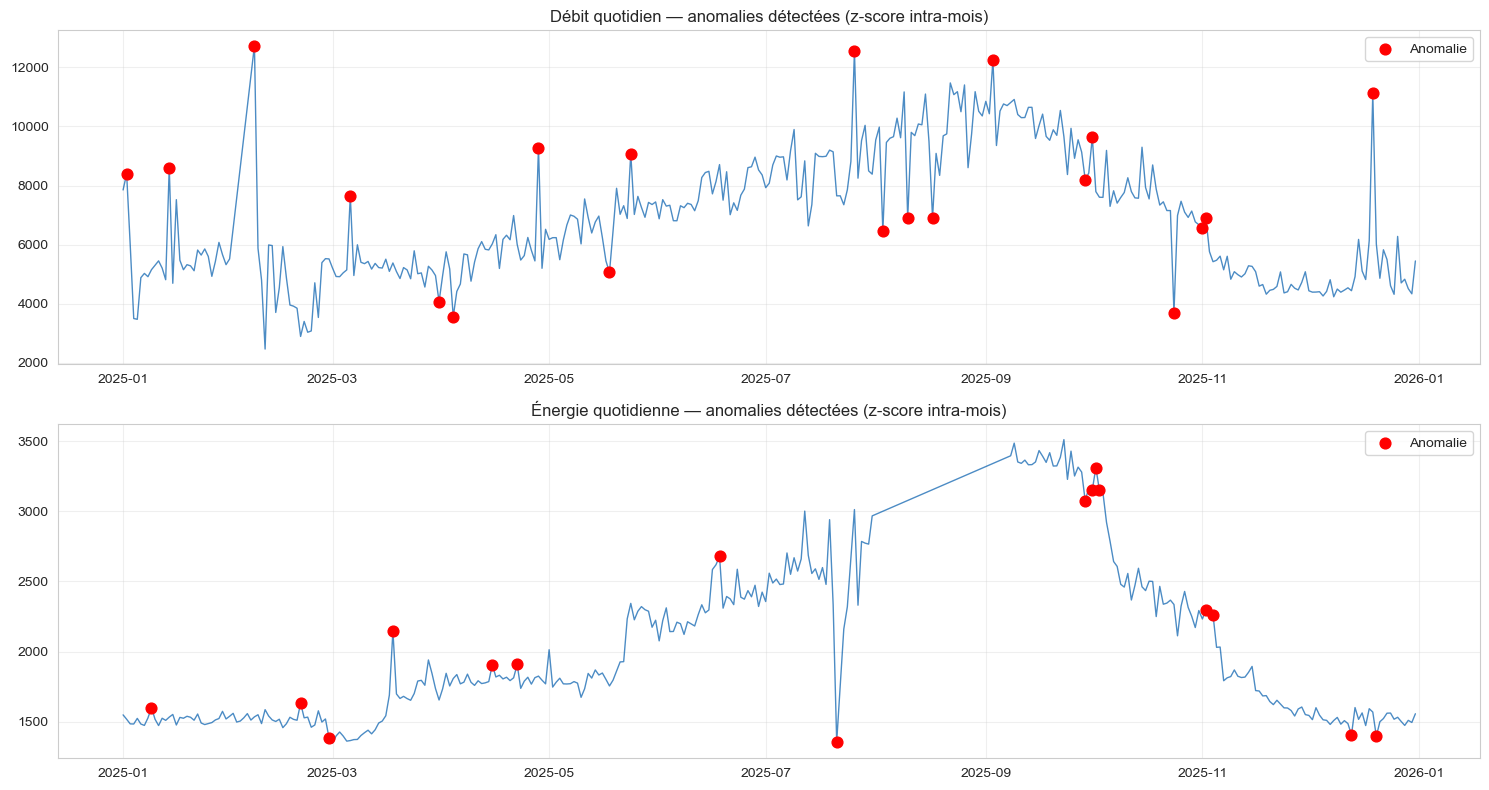

In [119]:
# ============================================================
# VISUALISATION : anomalies intra-mois sur débit et énergie
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

# Débit
ax = axes[0]
ax.plot(df_anom_debit["date"], df_anom_debit["debit_m3_jour"], color="#005BAC", linewidth=1, alpha=0.7)
anom = df_anom_debit[df_anom_debit["anomalie"]]
ax.scatter(anom["date"], anom["debit_m3_jour"], color="red", s=60, zorder=5, label="Anomalie")
ax.set_title("Débit quotidien — anomalies détectées (z-score intra-mois)")
ax.legend()
ax.grid(True, alpha=0.3)

# Énergie
ax = axes[1]
ax.plot(df_anom_energie["date"], df_anom_energie["energie_kwh_jour"], color="#005BAC", linewidth=1, alpha=0.7)
anom = df_anom_energie[df_anom_energie["anomalie"]]
ax.scatter(anom["date"], anom["energie_kwh_jour"], color="red", s=60, zorder=5, label="Anomalie")
ax.set_title("Énergie quotidienne — anomalies détectées (z-score intra-mois)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [129]:
# ============================================================
# INTERPRÉTATION : traduire chaque anomalie en langage clair
# ============================================================

jours_fr = {
    "Monday": "Lundi", "Tuesday": "Mardi", "Wednesday": "Mercredi",
    "Thursday": "Jeudi", "Friday": "Vendredi", "Saturday": "Samedi", "Sunday": "Dimanche"
}

def interpreter_anomalies(df_anom, col_valeur, nom_serie, unite):
    resultats = []
    for _, row in df_anom[df_anom["anomalie"]].iterrows():
        moyenne_mois = df_anom[df_anom["mois"] == row["mois"]][col_valeur].mean()
        ecart_pct = (row[col_valeur] - moyenne_mois) / moyenne_mois * 100
        direction = "au-dessus" if ecart_pct > 0 else "en-dessous"
        jour_semaine = jours_fr[pd.Timestamp(row["date"]).day_name()]

        resultats.append({
            "Date": row["date"].strftime("%d/%m/%Y") if hasattr(row["date"], 'strftime') else row["date"],
            "Jour": jour_semaine,
            "Valeur": f"{row[col_valeur]:,.0f} {unite}",
            "Moyenne du mois": f"{moyenne_mois:,.0f} {unite}",
            "Écart": f"{ecart_pct:+.0f}%",
            "Sens": direction
        })
    return pd.DataFrame(resultats)

print(f"=== {'DÉBIT'} — anomalies expliquées en langage clair ===")
resume_debit = interpreter_anomalies(df_anom_debit, "debit_m3_jour", "Débit", "m³/j")
resume_debit

=== DÉBIT — anomalies expliquées en langage clair ===


,Date,Jour,Valeur,Moyenne du mois,Écart,Sens
0,02/01/2025,Jeudi,"8,400 m³/j","5,584 m³/j",+50%,au-dessus
1,14/01/2025,Mardi,"8,609 m³/j","5,584 m³/j",+54%,au-dessus
2,07/02/2025,Vendredi,"12,735 m³/j","4,808 m³/j",+165%,au-dessus
3,06/03/2025,Jeudi,"7,647 m³/j","5,228 m³/j",+46%,au-dessus
4,31/03/2025,Lundi,"4,074 m³/j","5,228 m³/j",-22%,en-dessous
5,04/04/2025,Vendredi,"3,571 m³/j","5,753 m³/j",-38%,en-dessous
6,28/04/2025,Lundi,"9,278 m³/j","5,753 m³/j",+61%,au-dessus
7,18/05/2025,Dimanche,"5,062 m³/j","6,805 m³/j",-26%,en-dessous
8,24/05/2025,Samedi,"9,084 m³/j","6,805 m³/j",+33%,au-dessus
9,26/07/2025,Samedi,"12,556 m³/j","8,640 m³/j",+45%,au-dessus


In [131]:
print(f"=== ÉNERGIE — anomalies expliquées en langage clair ===")
resume_energie = interpreter_anomalies(df_anom_energie, "energie_kwh_jour", "Énergie", "kWh")
resume_energie

=== ÉNERGIE — anomalies expliquées en langage clair ===


,Date,Jour,Valeur,Moyenne du mois,Écart,Sens
0,09/01/2025,Jeudi,"1,602 kWh","1,519 kWh",+5%,au-dessus
1,20/02/2025,Jeudi,"1,633 kWh","1,519 kWh",+7%,au-dessus
2,28/02/2025,Vendredi,"1,387 kWh","1,519 kWh",-9%,en-dessous
3,18/03/2025,Mardi,"2,148 kWh","1,586 kWh",+35%,au-dessus
4,15/04/2025,Mardi,"1,908 kWh","1,803 kWh",+6%,au-dessus
5,22/04/2025,Mardi,"1,909 kWh","1,803 kWh",+6%,au-dessus
6,18/06/2025,Mercredi,"2,679 kWh","2,330 kWh",+15%,au-dessus
7,21/07/2025,Lundi,"1,358 kWh","2,559 kWh",-47%,en-dessous
8,29/09/2025,Lundi,"3,074 kWh","3,340 kWh",-8%,en-dessous
9,01/10/2025,Mercredi,"3,153 kWh","2,533 kWh",+24%,au-dessus


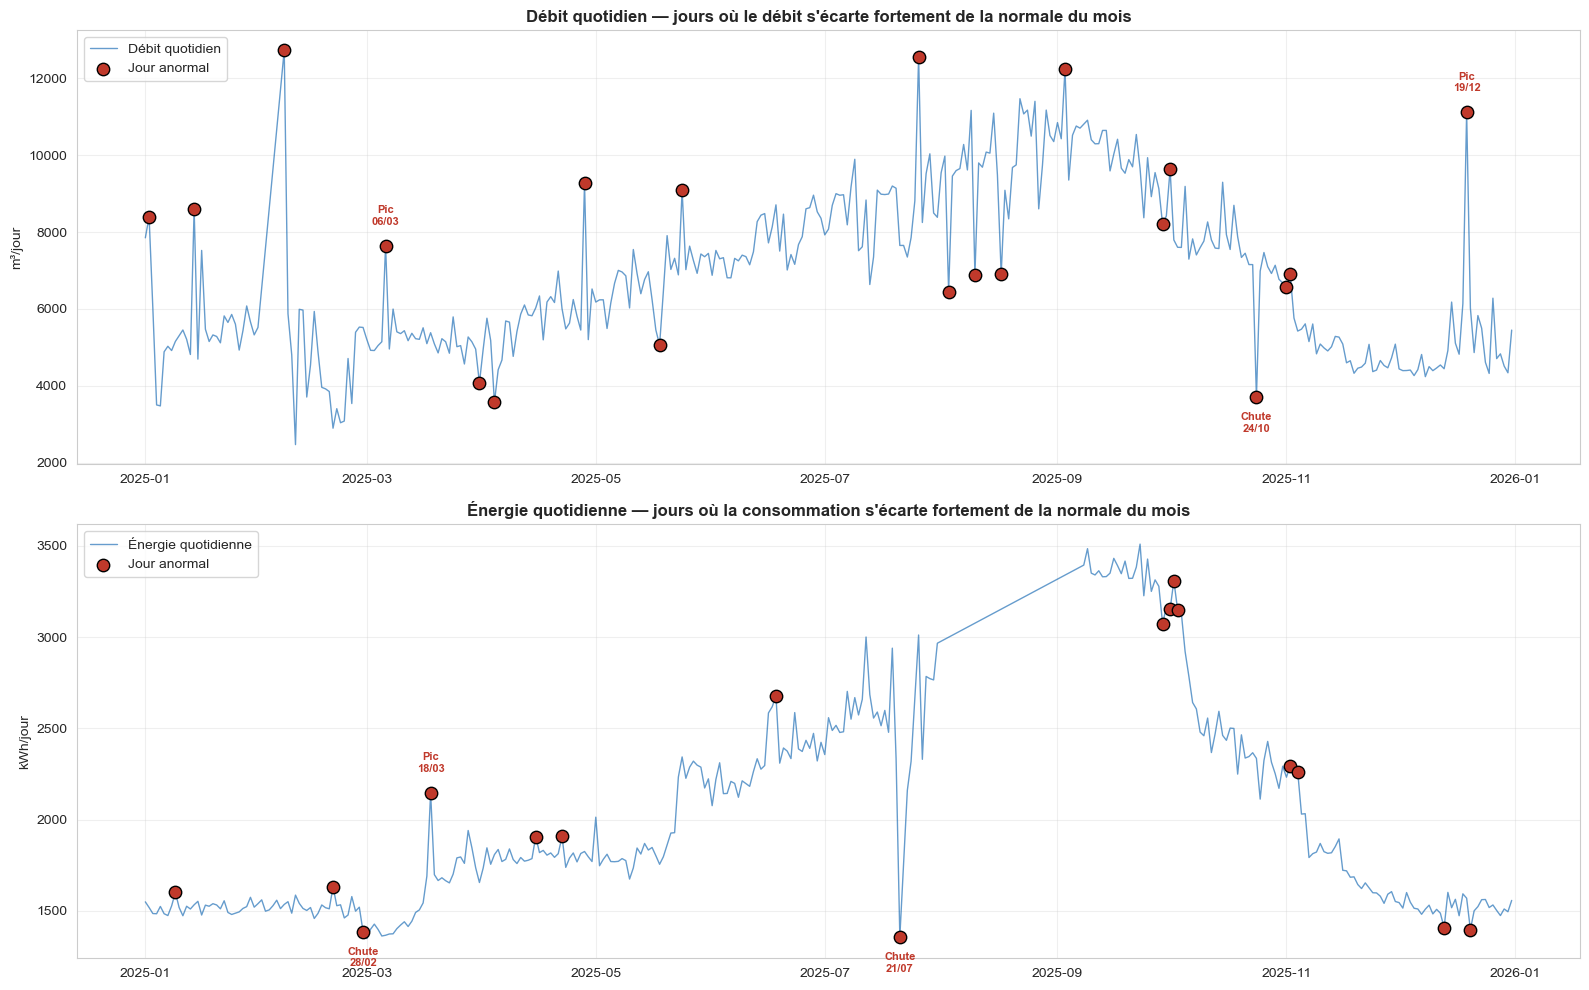

In [133]:
# ============================================================
# VISUALISATION ENRICHIE : anomalies avec explication visuelle
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# --- Débit ---
ax = axes[0]
ax.plot(df_anom_debit["date"], df_anom_debit["debit_m3_jour"], color="#005BAC", linewidth=1, alpha=0.6, label="Débit quotidien")
anom = df_anom_debit[df_anom_debit["anomalie"]]
ax.scatter(anom["date"], anom["debit_m3_jour"], color="#C0392B", s=80, zorder=5, edgecolor="black", label="Jour anormal")

# Annoter seulement les 3 anomalies les plus extrêmes (pour ne pas surcharger)
top3 = anom.reindex(anom["z_score_intra_mois"].abs().sort_values(ascending=False).index).head(3)
for _, row in top3.iterrows():
    signe = "Pic" if row["z_score_intra_mois"] > 0 else "Chute"
    ax.annotate(f"{signe}\n{row['date'].strftime('%d/%m')}",
                xy=(row["date"], row["debit_m3_jour"]),
                xytext=(0, 15 if row["z_score_intra_mois"] > 0 else -25),
                textcoords="offset points", fontsize=8, ha="center", fontweight="bold",
                color="#C0392B")

ax.set_title("Débit quotidien — jours où le débit s'écarte fortement de la normale du mois", fontsize=12, fontweight="bold")
ax.set_ylabel("m³/jour")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# --- Énergie ---
ax = axes[1]
ax.plot(df_anom_energie["date"], df_anom_energie["energie_kwh_jour"], color="#005BAC", linewidth=1, alpha=0.6, label="Énergie quotidienne")
anom = df_anom_energie[df_anom_energie["anomalie"]]
ax.scatter(anom["date"], anom["energie_kwh_jour"], color="#C0392B", s=80, zorder=5, edgecolor="black", label="Jour anormal")

top3 = anom.reindex(anom["z_score_intra_mois"].abs().sort_values(ascending=False).index).head(3)
for _, row in top3.iterrows():
    signe = "Pic" if row["z_score_intra_mois"] > 0 else "Chute"
    ax.annotate(f"{signe}\n{row['date'].strftime('%d/%m')}",
                xy=(row["date"], row["energie_kwh_jour"]),
                xytext=(0, 15 if row["z_score_intra_mois"] > 0 else -25),
                textcoords="offset points", fontsize=8, ha="center", fontweight="bold",
                color="#C0392B")

ax.set_title("Énergie quotidienne — jours où la consommation s'écarte fortement de la normale du mois", fontsize=12, fontweight="bold")
ax.set_ylabel("kWh/jour")
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [135]:
# ============================================================
# TEST DE COHÉRENCE : la méthode retrouve-t-elle les anomalies déjà connues ?
# ============================================================
print("Rappel : anomalies déjà identifiées et corrigées en amont (ETL) :")
print("- Débit : novembre 2025")
print("- DCO : octobre/décembre 2025")
print()
print("Anomalies détectées dans debit_m3_jour sur novembre :")
print(resume_debit[resume_debit["Date"].str.contains("/11/2025")])

Rappel : anomalies déjà identifiées et corrigées en amont (ETL) :
- Débit : novembre 2025
- DCO : octobre/décembre 2025

Anomalies détectées dans debit_m3_jour sur novembre :
          Date      Jour      Valeur Moyenne du mois Écart       Sens
17  01/11/2025    Samedi  6,571 m³/j      5,048 m³/j  +30%  au-dessus
18  02/11/2025  Dimanche  6,899 m³/j      5,048 m³/j  +37%  au-dessus


## Anomaly Detection — Volet A : anomalies sur les données réelles

**Méthode retenue** : Z-score intra-mois (écart à la moyenne du même mois, seuil ±2σ), 
appliqué sur les données quotidiennes réelles — pas sur les résidus de prévision.

**Pourquoi intra-mois plutôt que global** : la forte saisonnalité des séries (débit, énergie) 
rend un seuil global (IQR ou Z-score sur toute l'année) peu sensible aux écarts locaux 
(un jour bas en été peut être "normal" globalement mais anormal pour l'été). Comparer 
chaque jour à la moyenne de son propre mois isole les vraies ruptures de comportement.

**Champ d'application** :
- Débit et énergie : détection quotidienne (359 et 325 points valides respectivement)
- Charge organique et boues : détection mensuelle (12 points réels) — pas de vraie 
  granularité quotidienne disponible pour ces deux mesures (confirmé par diagnostic : 
  charge = saisie mensuelle unique, boues = données événementielles non continues)

**Résultats** : 20 jours anormaux détectés sur le débit, 16 sur l'énergie, 0 sur charge/boues 
mensuelles (cohérent avec le nettoyage ETL déjà effectué en amont sur ces séries).

**Signal notable** : convergence d'anomalies sur les deux séries aux mêmes dates 
(29/09-03/10, 02/11) — suggère un événement d'exploitation réel plutôt qu'un bruit statistique 
isolé, car un incident physique (panne, maintenance) affecte typiquement plusieurs mesures 
simultanément.

**Test de cohérence** : les anomalies de saisie déjà corrigées en amont (débit novembre, 
DCO octobre/décembre) ne réapparaissent plus dans les résidus consolidés — validation 
indirecte de l'efficacité du nettoyage ETL.

**Limite assumée** : seuil ±2σ sur 12 points (charge/boues) reste indicatif, pas 
statistiquement rigoureux — cohérent avec l'esprit du projet (éviter la sur-ingénierie 
sur des séries courtes).

In [139]:
# ============================================================
# VOLET B — EXPLORATION : équipements disponibles et densité de données
# ============================================================
query_equip = """
SELECT 
    code_equipement,
    COUNT(*) AS nb_lignes,
    COUNT(DISTINCT f.pk_date) AS nb_jours,
    ROUND(AVG(heures_marche), 2) AS moy_heures_marche,
    ROUND(AVG(energie_active_kwh), 2) AS moy_energie_kwh,
    ROUND(AVG(debit_moyen_m3h), 2) AS moy_debit_m3h,
    ROUND(AVG(cos_phi), 3) AS moy_cos_phi
FROM fait_equipement_exploitation f
JOIN dim_temps dt ON dt.pk_date = f.pk_date
WHERE dt.annee = 2025
GROUP BY code_equipement
ORDER BY nb_lignes DESC;
"""
df_equip = pd.read_sql(text(query_equip), engine)
df_equip

,code_equipement,nb_lignes,nb_jours,moy_heures_marche,moy_energie_kwh,moy_debit_m3h,moy_cos_phi
0,Pompe boues de retour 1,357,357,3.93,NaN,NaN,NaN
1,Pompe boues de retour 2,357,357,3.40,NaN,NaN,NaN
2,Pont Décanteur 2,357,357,13.56,NaN,NaN,NaN
3,Brosse Décanteur 1,357,357,12.88,NaN,NaN,NaN
4,Brosse Décanteur 2,357,357,8.01,NaN,NaN,NaN
5,Pont Décanteur 1,357,357,21.70,NaN,NaN,NaN
6,Pompe boues de retour 3,357,357,3.75,NaN,NaN,NaN
7,Unité traitement d'odeur 3,355,355,23.95,NaN,NaN,NaN
8,Pompe boues en excès 2,355,355,1.30,NaN,NaN,NaN
9,Pompe boues en excès 1,355,355,1.32,NaN,NaN,NaN


In [141]:
# ============================================================
# VOLET B — VÉRIFICATION : que mesure-t-on pour SONEDE et Débitmétre ?
# ============================================================
query_check = """
SELECT code_equipement,
       ROUND(AVG(consommation_m3), 2) AS moy_consommation_m3,
       ROUND(AVG(index_compteur), 2) AS moy_index_compteur,
       ROUND(AVG(debit_moyen_m3h), 2) AS moy_debit_m3h,
       ROUND(AVG(heures_marche), 2) AS moy_heures_marche
FROM fait_equipement_exploitation f
JOIN dim_temps dt ON dt.pk_date = f.pk_date
WHERE dt.annee = 2025 AND code_equipement IN ('SONEDE', 'Débitmétre')
GROUP BY code_equipement;
"""
df_check = pd.read_sql(text(query_check), engine)
df_check

,code_equipement,moy_consommation_m3,moy_index_compteur,moy_debit_m3h,moy_heures_marche
0,Débitmétre,NaN,8841224.65,270.4,None
1,SONEDE,0.77,17736.57,NaN,None


In [143]:
# ============================================================
# VOLET B — CHARGEMENT : données quotidiennes par équipement
# ============================================================
query_equip_detail = """
SELECT 
    dt.date, dt.mois,
    f.code_equipement,
    f.heures_marche,
    f.debit_moyen_m3h,
    f.consommation_m3
FROM fait_equipement_exploitation f
JOIN dim_temps dt ON dt.pk_date = f.pk_date
WHERE dt.annee = 2025 AND f.code_equipement != 'ENERGIE'
ORDER BY f.code_equipement, dt.date;
"""
df_equip_detail = pd.read_sql(text(query_equip_detail), engine)
print(df_equip_detail.shape)
df_equip_detail.head()

(17673, 6)


,date,mois,code_equipement,heures_marche,debit_moyen_m3h,consommation_m3
0,2025-01-01,1,Agitateur 1,15.0,NaN,NaN
1,2025-01-02,1,Agitateur 1,15.0,NaN,NaN
2,2025-01-03,1,Agitateur 1,14.0,NaN,NaN
3,2025-01-04,1,Agitateur 1,15.0,NaN,NaN
4,2025-01-05,1,Agitateur 1,17.0,NaN,NaN


In [145]:
# ============================================================
# VOLET B — DÉTECTION : z-score intra-mois, par équipement
# ============================================================

def detecter_anomalies_equipement(df, code_equip, col_valeur, seuil=2):
    sous_df = df[df["code_equipement"] == code_equip].dropna(subset=[col_valeur]).copy()
    if len(sous_df) < 20:  # trop peu de données pour un z-score fiable
        return None

    moyenne_mois = sous_df.groupby("mois")[col_valeur].transform("mean")
    ecart_type_mois = sous_df.groupby("mois")[col_valeur].transform("std")
    sous_df["z_score"] = (sous_df[col_valeur] - moyenne_mois) / ecart_type_mois
    sous_df["anomalie"] = sous_df["z_score"].abs() > seuil
    return sous_df

# Détermine la colonne pertinente par équipement
resultats_equip = []
liste_equipements = df_equip_detail["code_equipement"].unique()

for equip in liste_equipements:
    if equip == "Débitmétre":
        col = "debit_moyen_m3h"
    elif equip == "SONEDE":
        col = "consommation_m3"
    else:
        col = "heures_marche"

    res = detecter_anomalies_equipement(df_equip_detail, equip, col)
    if res is not None:
        n_anom = res["anomalie"].sum()
        resultats_equip.append({
            "Équipement": equip,
            "Mesure utilisée": col,
            "Points valides": len(res),
            "Anomalies détectées": n_anom,
            "% anormal": round(n_anom / len(res) * 100, 1)
        })

df_synthese_equip = pd.DataFrame(resultats_equip).sort_values("Anomalies détectées", ascending=False)
df_synthese_equip

,Équipement,Mesure utilisée,Points valides,Anomalies détectées,% anormal
39,Surpresseur d'aération 4,heures_marche,322,32,9.9
38,Surpresseur d'aération 3,heures_marche,322,29,9.0
23,Pompe boues en excès 1,heures_marche,354,27,7.6
16,Dégrilleur 2,heures_marche,325,26,8.0
36,Surpresseur d'aération 1,heures_marche,324,26,8.0
21,Pompe boues de retour 2,heures_marche,356,24,6.7
29,Pompe eaux internes 1,heures_marche,353,23,6.5
22,Pompe boues de retour 3,heures_marche,356,23,6.5
2,Agitateur 3,heures_marche,322,22,6.8
3,Agitateur 4,heures_marche,322,22,6.8


Équipements analysés en détail : ["Surpresseur d'aération 4", "Surpresseur d'aération 3", 'Pompe boues en excès 1', 'Dégrilleur 2', "Surpresseur d'aération 1", 'Pompe boues de retour 2']


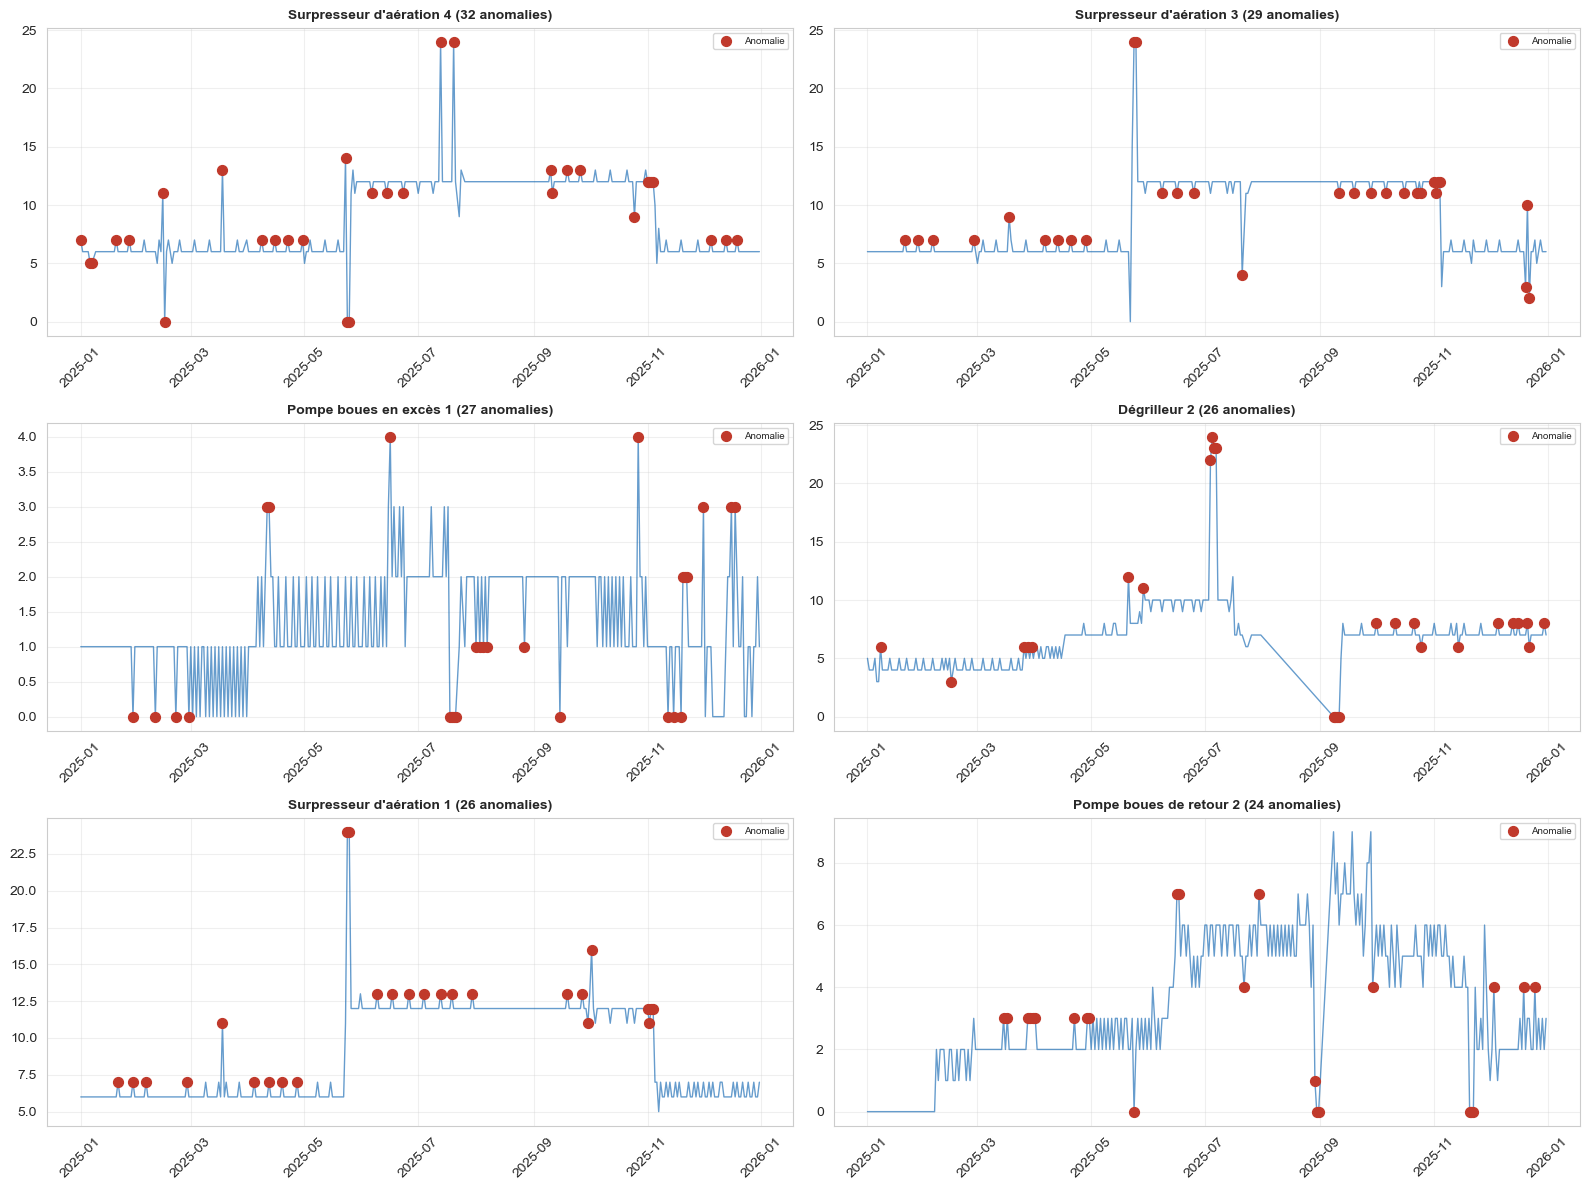

In [147]:
# ============================================================
# VOLET B — ZOOM : visualisation des équipements les plus anormaux
# ============================================================
top_equip = df_synthese_equip.head(6)["Équipement"].tolist()
print("Équipements analysés en détail :", top_equip)

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for i, equip in enumerate(top_equip):
    col = "debit_moyen_m3h" if equip == "Débitmétre" else ("consommation_m3" if equip == "SONEDE" else "heures_marche")
    res = detecter_anomalies_equipement(df_equip_detail, equip, col)

    ax = axes[i]
    ax.plot(res["date"], res[col], color="#005BAC", linewidth=1, alpha=0.6)
    anom = res[res["anomalie"]]
    ax.scatter(anom["date"], anom[col], color="#C0392B", s=50, zorder=5, label="Anomalie")

    ax.set_title(f"{equip} ({res['anomalie'].sum()} anomalies)", fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [149]:
# ============================================================
# VOLET B — RAFFINEMENT : distinguer transition saisonnière vs vraie rupture
# ============================================================
# Une anomalie "transition" apparaît isolée entre deux paliers stables
# Une anomalie "rupture" (chute à 0 ou pic extrême) apparaît AU MILIEU d'un palier stable

def classifier_anomalies(res, col_valeur, fenetre=5):
    res = res.sort_values("date").reset_index(drop=True)
    res["mediane_glissante"] = res[col_valeur].rolling(fenetre, center=True, min_periods=1).median()
    res["ecart_mediane_locale"] = (res[col_valeur] - res["mediane_glissante"]).abs()

    # Rupture nette = anomalie + écart fort à la médiane locale (pas juste au mois)
    res["type_anomalie"] = "normal"
    res.loc[res["anomalie"] & (res["ecart_mediane_locale"] > res[col_valeur].std() * 0.5), "type_anomalie"] = "Rupture probable (panne/arrêt)"
    res.loc[res["anomalie"] & (res["ecart_mediane_locale"] <= res[col_valeur].std() * 0.5), "type_anomalie"] = "Transition de régime (saisonnier)"
    return res

for equip in top_equip:
    col = "debit_moyen_m3h" if equip == "Débitmétre" else ("consommation_m3" if equip == "SONEDE" else "heures_marche")
    res = detecter_anomalies_equipement(df_equip_detail, equip, col)
    res_classe = classifier_anomalies(res, col)
    ruptures = res_classe[res_classe["type_anomalie"] == "Rupture probable (panne/arrêt)"]
    print(f"{equip} — Ruptures probables (vraies anomalies à investiguer) : {len(ruptures)}")
    if len(ruptures) > 0:
        print(ruptures[["date", col, "type_anomalie"]])
    print()

Surpresseur d'aération 4 — Ruptures probables (vraies anomalies à investiguer) : 9
           date  heures_marche                   type_anomalie
43   2025-02-14           11.0  Rupture probable (panne/arrêt)
44   2025-02-15            0.0  Rupture probable (panne/arrêt)
75   2025-03-18           13.0  Rupture probable (panne/arrêt)
140  2025-05-23           14.0  Rupture probable (panne/arrêt)
141  2025-05-24            0.0  Rupture probable (panne/arrêt)
142  2025-05-25            0.0  Rupture probable (panne/arrêt)
191  2025-07-13           24.0  Rupture probable (panne/arrêt)
198  2025-07-20           24.0  Rupture probable (panne/arrêt)
254  2025-10-25            9.0  Rupture probable (panne/arrêt)

Surpresseur d'aération 3 — Ruptures probables (vraies anomalies à investiguer) : 7
           date  heures_marche                   type_anomalie
75   2025-03-18            9.0  Rupture probable (panne/arrêt)
141  2025-05-24           24.0  Rupture probable (panne/arrêt)
142  2025-05-2

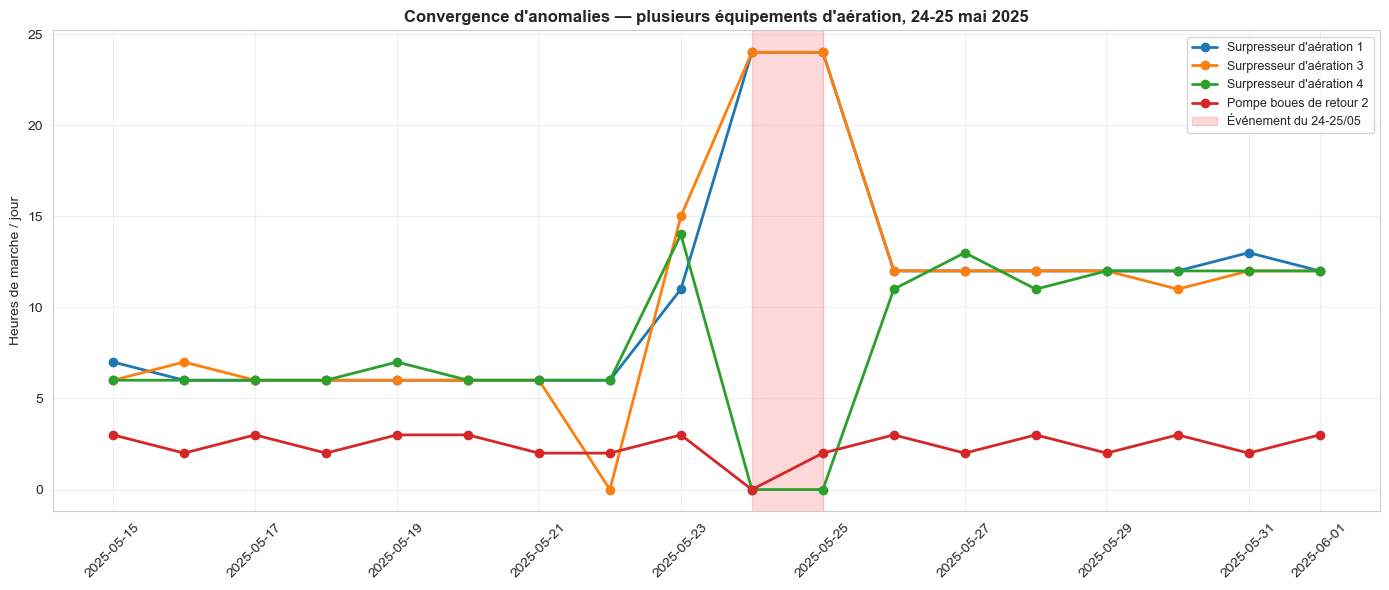

In [153]:
# ============================================================
# VOLET B — SIGNAL CLÉ : convergence multi-équipements du 24-25 mai
# ============================================================
equipements_convergence = ["Surpresseur d'aération 1", "Surpresseur d'aération 3",
                            "Surpresseur d'aération 4", "Pompe boues de retour 2"]

fig, ax = plt.subplots(figsize=(14, 6))

for equip in equipements_convergence:
    res = detecter_anomalies_equipement(df_equip_detail, equip, "heures_marche")
    res["date"] = pd.to_datetime(res["date"])  # conversion explicite
    zoom = res[(res["date"] >= "2025-05-15") & (res["date"] <= "2025-06-01")]
    ax.plot(zoom["date"], zoom["heures_marche"], marker="o", label=equip, linewidth=2)

ax.axvspan(pd.Timestamp("2025-05-24"), pd.Timestamp("2025-05-25"), alpha=0.15, color="red", label="Événement du 24-25/05")
ax.set_title("Convergence d'anomalies — plusieurs équipements d'aération, 24-25 mai 2025", fontsize=12, fontweight="bold")
ax.set_ylabel("Heures de marche / jour")
ax.tick_params(axis="x", rotation=45)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Anomaly Detection — Volet B : anomalies au niveau équipement

**Méthode** : Z-score intra-mois (identique au Volet A pour la cohérence méthodologique), 
appliqué sur `heures_marche` pour ~50 équipements, `debit_moyen_m3h` pour le Débitmètre, 
et `consommation_m3` pour SONEDE. L'énergie globale (ENERGIE) reste couverte par le Volet A.

**Raffinement nécessaire** : le z-score intra-mois seul confondait deux phénomènes distincts 
sur les équipements à forte saisonnalité (surpresseurs d'aération notamment) : les transitions 
de régime saisonnier (été/hiver, normales) et les vraies ruptures ponctuelles (arrêts/pics, 
anormales). Une classification complémentaire (écart à la médiane glissante locale) a permis 
de séparer les deux.

**Résultat principal — convergence du 23-24 mai 2025** : quatre équipements liés à l'aération 
(Surpresseurs 1, 3, 4 et Pompe boues de retour 2) montrent une bascule simultanée et opposée 
(deux équipements à 24h/24, deux à l'arrêt complet), suivie d'un retour à un nouveau palier 
stable. Ce pattern suggère une opération de maintenance ou un arrêt planifié compensé par 
les équipements restants — hypothèse à valider auprès de l'exploitant.

**Valeur ajoutée du Volet B** : ce type d'événement (compensation de charge entre équipements 
lors d'un arrêt) est invisible dans les séries agrégées mensuelles du Volet A — seule la 
granularité équipement × jour permet de le détecter, ce qui justifie l'ajout de ce second 
volet au-delà des résidus de prévision globale.

**Limite assumée** : le seuil ±2σ reste indicatif ; l'interprétation causale (maintenance, 
panne) est une hypothèse statistique, pas une confirmation — nécessite une validation 
terrain/métier pour être définitive.